# Manual split and ring audit

One cell per training fragment from `assemble_training_segments.py` (32 fragments; the w055 holdout is excluded),
grouped by physical scroll: PHerc0139, PHerc1667, PHerc0172, then single-patch scrolls.
Fragments with an official 2026-09-18 researcher label in `INKLABEL_DIR` (`researcher_inklabels/`) use it;
all others fall back to `FALLBACK_INKLABEL_DIR`. Researcher-label fragments: w044, w035, w013, w018,
PHerc0009B 487, PHercParis4, PHerc0814, PHerc0841.

- **red**: ordinary training positive
- **magenta**: explicit positive (`185` in `train_masks`)
- **yellow**: training ring negative
- **blue**: validation positive
- **green**: validation ring negative
- **cyan**: explicit negative (`119` in `train_masks`)
- **gray**: researcher `inklabels/2_4um` reference

The renderer uses the selected label directory, `CLOSE_R`, `GAP_R`, `SHELL_R`, and `POS_ONLY` values as the actual dataset configuration.

In [5]:
CLOSE_R = 0
GAP_R = 0
SHELL_R = 4
INKLABEL_DIR = "./dilated_inklabels"
FALLBACK_INKLABEL_DIR = "./inklabels"  # used for fragments without a file in INKLABEL_DIR
POS_ONLY = False

In [6]:
from pathlib import Path
import gc
import importlib

import cv2
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

import utils.config as config_module
import utils.dataloader as dataloader_module

ROOT = Path.cwd()
if ROOT.name == "old":
    ROOT = ROOT.parent

config_module = importlib.reload(config_module)
campaign29_module = importlib.import_module("campaign_archs_29")
campaign29_module = importlib.reload(campaign29_module)
dataloader_module = importlib.reload(dataloader_module)
CAMPAIGN28_SCROLL_DICT = campaign29_module.CAMPAIGN28_SCROLL_DICT
CAMPAIGN28_SCROLL_IDS = campaign29_module.CAMPAIGN28_SCROLL_IDS
TESTS = campaign29_module.TESTS
build_config = campaign29_module.build_config
DataManager = dataloader_module.DataManager
SAVE_PNG = True
OUT_DIR = ROOT / "output" / "manual_split_audit"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SCROLL_NAMES = {
    20260115000000: "PHerc0139 w044",
    20260317000000: "PHerc0139 w035",
    20250223000000: "PHerc0139 w059",
    20251111010954: "PHerc0172 w068",
    20251112000002: "PHerc0172 w087",
    20240304141531: "PHerc1667 w013",
    20240304144031: "PHerc1667 w018",
    20231201215900: "PHerc1667 Cr1 Fr3",
    20250919125754: "PHerc0009B 487",
    20231210121321: "PHercParis4",
    20250628074500: "PHerc0500P2",
    20260226000000: "PHerc0814",
    20230301213755: "PHercParis2 Fr143",
    20231205222200: "PHerc51 Cr4 Fr8",
    20230301213423: "PHercParis1 Fr34",
    20250511003658: "PHerc0343P",
    20260221022814: "PHerc0841",
    20260206000001: "PHerc0139 w047",
    20260115000001: "PHerc0139 w056",
    20260210000000: "PHerc0139 w058",
    20260227000000: "PHerc0139 w052",
    20260318000000: "PHerc0139 w049",
    20260325000000: "PHerc0139 w046",
    20260108000000: "PHerc0139 w041",
    20250831000000: "PHerc0139 w040",
    20260302000000: "PHerc0139 w039",
    20260306000000: "PHerc0139 w038",
    20260310000000: "PHerc0139 w037",
    20260303000000: "PHerc0139 w034",
    20250108000005: "PHerc0139 w030",
    20260112000000: "PHerc0139 w043",
    20260126000000: "PHerc0139 w045",
}
assert set(CAMPAIGN28_SCROLL_IDS) <= set(SCROLL_NAMES)
SCROLL_ORDER = list(SCROLL_NAMES)

DOMAIN_BY_SCROLL = {
    scroll_id: domain_index
    for domain_index, scroll_ids in enumerate(CAMPAIGN28_SCROLL_DICT.values())
    for scroll_id in scroll_ids
}
PHERC0139_DOMAIN = DOMAIN_BY_SCROLL[20260115000000]
for _scroll_id, _name in SCROLL_NAMES.items():
    if _name.startswith("PHerc0139"):
        DOMAIN_BY_SCROLL.setdefault(_scroll_id, PHERC0139_DOMAIN)

COLORS = {
    "train_positive": np.array([255, 0, 0], dtype=np.uint8),
    "explicit_positive": np.array([255, 0, 220], dtype=np.uint8),
    "train_negative": np.array([255, 220, 0], dtype=np.uint8),
    "valid_positive": np.array([0, 90, 255], dtype=np.uint8),
    "valid_negative": np.array([0, 190, 70], dtype=np.uint8),
    "explicit_negative": np.array([0, 255, 255], dtype=np.uint8),
}


def label_dir_for(scroll_id):
    if (ROOT / INKLABEL_DIR / f"{scroll_id}.png").exists():
        return INKLABEL_DIR
    return FALLBACK_INKLABEL_DIR


def audit_config(scroll_id):
    config = build_config(TESTS[0])
    config.data.inklabel_dir = label_dir_for(scroll_id)
    config.data.ring_close_r = CLOSE_R
    config.data.ring_gap_r = GAP_R
    config.data.ring_shell_r = SHELL_R
    config.data.multitile_pos_only = POS_ONLY
    config.data.multitile_ring_gate = True
    config.data.ring_from_inklabel_dir = True
    config.data.preload_volumes = False
    config.data.selective_chunk_preload = False
    config.data.mask_memmap = False
    config.data.mask_bitpack = False
    config.data.character_balanced_sampling = False
    config.tra.character_macro_metrics = False
    config.dl.data_aug = False
    return config


print(
    f"Audit ready: {len(SCROLL_NAMES)} fragments, "
    f"labels={INKLABEL_DIR} (fallback {FALLBACK_INKLABEL_DIR}), "
    f"close={CLOSE_R}, gap={GAP_R}, shell={SHELL_R}, pos_only={POS_ONLY}"
)

Audit ready: 32 fragments, labels=./dilated_inklabels (fallback ./inklabels), close=0, gap=0, shell=4, pos_only=False


In [7]:
OVERLAY_ALPHA = 0.5


def _blend(rgb, selected, color):
    if not np.any(selected):
        return
    rgb[selected] = np.clip(
        (1.0 - OVERLAY_ALPHA) * rgb[selected].astype(np.float32)
        + OVERLAY_ALPHA * np.asarray(color, dtype=np.float32),
        0,
        255,
    ).astype(np.uint8)


def _empty_maps(shape):
    return {name: np.zeros(shape, dtype=bool) for name in COLORS}


def _collect_targets(dataset, maps, split):
    n = dataset._mt_grid
    sub = dataset._mt_sub
    explicit_positive_mask = dataset.explicit_positive_mask
    stats = {
        "windows": len(dataset.block_coords),
        "positive_occurrences": 0,
        "negative_occurrences": 0,
        "explicit_positive_occurrences": 0,
        "explicit_negative_occurrences": 0,
    }
    for _, y_off, x_off in dataset.block_coords:
        labels = dataset._fetch_label_mt(y_off, x_off).numpy()
        valid = dataset._fetch_mask_mt(y_off, x_off).numpy() > 0
        y0, _, x0, _ = dataset._mt_center_bounds(y_off, x_off)
        for index in np.flatnonzero(valid):
            iy, ix = divmod(int(index), n)
            ys, ye = y0 + iy * sub, y0 + (iy + 1) * sub
            xs, xe = x0 + ix * sub, x0 + (ix + 1) * sub
            cy = (ys + sub // 2) // sub
            cx = (xs + sub // 2) // sub
            if not (0 <= cy < maps["train_positive"].shape[0] and 0 <= cx < maps["train_positive"].shape[1]):
                continue
            if labels[index] < 0:
                maps["explicit_negative"][cy, cx] = True
                stats["explicit_negative_occurrences"] += 1
            elif labels[index] > 0:
                explicit = explicit_positive_mask is not None and np.any(
                    explicit_positive_mask[ys:ye, xs:xe] > 0
                )
                key = "explicit_positive" if explicit else f"{split}_positive"
                maps[key][cy, cx] = True
                stats["explicit_positive_occurrences" if explicit else "positive_occurrences"] += 1
            else:
                maps[f"{split}_negative"][cy, cx] = True
                stats["negative_occurrences"] += 1
    return stats


def render_scroll(scroll_id, name):
    config = audit_config(scroll_id)
    label_dir = config.data.inklabel_dir
    scroll_index = SCROLL_ORDER.index(int(scroll_id))
    manager = DataManager(
        config,
        scroll_id=int(scroll_id),
        domain_id=DOMAIN_BY_SCROLL[int(scroll_id)],
        character_namespace=scroll_index,
    )
    train_set, valid_set = manager.get_datasets()

    height, width = manager.labels.shape
    sub = int(config.model.multitile_subtile)
    shape = (int(np.ceil(height / sub)) + 1, int(np.ceil(width / sub)) + 1)
    maps = _empty_maps(shape)
    train_stats = _collect_targets(train_set, maps, "train")
    valid_stats = _collect_targets(valid_set, maps, "valid")

    train_any = maps["train_positive"] | maps["explicit_positive"] | maps["train_negative"] | maps["explicit_negative"]
    valid_any = maps["valid_positive"] | maps["valid_negative"]
    assert not np.any(train_any & valid_any), f"train/validation overlap for {scroll_id}"

    reference_path = ROOT / "inklabels" / "2_4um" / f"{scroll_id}.png"
    reference = cv2.imread(str(reference_path), cv2.IMREAD_GRAYSCALE)
    if reference is None:
        reference_path = ROOT / "inklabels" / f"{scroll_id}.png"
        reference = cv2.imread(str(reference_path), cv2.IMREAD_GRAYSCALE)
    background = cv2.resize(reference, (shape[1], shape[0]), interpolation=cv2.INTER_AREA)
    rgb = np.repeat(background[..., None], 3, axis=2).astype(np.uint8)
    for key in ("train_negative", "valid_negative", "train_positive", "valid_positive", "explicit_positive", "explicit_negative"):
        _blend(rgb, maps[key], COLORS[key])

    counts = {key: int(value.sum()) for key, value in maps.items()}
    figure, axis = plt.subplots(figsize=(18, max(6, 18 * height / width)))
    axis.imshow(rgb, interpolation="nearest")
    axis.set_title(
        f"{name} — {scroll_id}\n"
        f"labels={label_dir}, closed c{CLOSE_R}/g{GAP_R}/s{SHELL_R}, "
        f"pos_only={POS_ONLY}; background=inklabels/2_4um"
    )
    axis.axis("off")
    axis.legend(handles=[
        mpatches.Patch(color=COLORS["train_positive"] / 255, alpha=OVERLAY_ALPHA, label=f"train positive ({counts['train_positive']:,})"),
        mpatches.Patch(color=COLORS["explicit_positive"] / 255, alpha=OVERLAY_ALPHA, label=f"explicit positive ({counts['explicit_positive']:,})"),
        mpatches.Patch(color=COLORS["train_negative"] / 255, alpha=OVERLAY_ALPHA, label=f"train ring negative ({counts['train_negative']:,})"),
        mpatches.Patch(color=COLORS["valid_positive"] / 255, alpha=OVERLAY_ALPHA, label=f"validation positive ({counts['valid_positive']:,})"),
        mpatches.Patch(color=COLORS["valid_negative"] / 255, alpha=OVERLAY_ALPHA, label=f"validation ring negative ({counts['valid_negative']:,})"),
        mpatches.Patch(color=COLORS["explicit_negative"] / 255, alpha=OVERLAY_ALPHA, label=f"explicit negative ({counts['explicit_negative']:,})"),
        mpatches.Patch(color=(0.5, 0.5, 0.5), label="researcher 2.4um reference"),
    ], loc="upper right", fontsize=9, framealpha=0.95)
    plt.tight_layout()

    output_path = OUT_DIR / f"{scroll_id}_split_c{CLOSE_R}_g{GAP_R}_s{SHELL_R}_{Path(label_dir).name}.png"
    if SAVE_PNG:
        figure.savefig(output_path, dpi=180, bbox_inches="tight")
        print(f"saved {output_path}")
    print("unique targets", counts)
    print("train occurrences", train_stats)
    print("valid occurrences", valid_stats)
    plt.show()

    del train_set, valid_set, manager, reference, background, rgb, maps
    gc.collect()
    return counts


print("Renderer ready")

Renderer ready


[align] scroll 20260115000000: volume=(6040, 8160) mask=(6040, 8160) labels=(6040, 8160) -> common=(6029, 8141)
[explicit-negative] scroll 20260115000000: overriding 2,393 ink-label pixels
[split] scroll 20260115000000: manual mask=./train_masks/20260115000000.png train_pixels=4.2% explicit_negative_pixels=641,792 explicit_positive_pixels=164,775
[split] scroll 20260115000000: axis=y train_frac=0.8055
[ring] closed(base=regular): CLOSE_R=0 GAP_R=0 exclusion_tiles=2237
[ring_negatives] source='closed' tile_radius=4  ink_tiles=3235  ring_tiles=3773  ratio=1.17
[manual-split] scroll 20260115000000: unit=16px train_ring=1395200px valid_ring=392960px
[context-replace] scroll 20260115000000: 2177 fully ink-free donors with mask>=0.80
saved /vesuvius/output/manual_split_audit/20260115000000_split_c0_g0_s4_dilated_inklabels.png
unique targets {'train_positive': 1656, 'explicit_positive': 624, 'train_negative': 1882, 'valid_positive': 578, 'valid_negative': 742, 'explicit_negative': 2005}
train

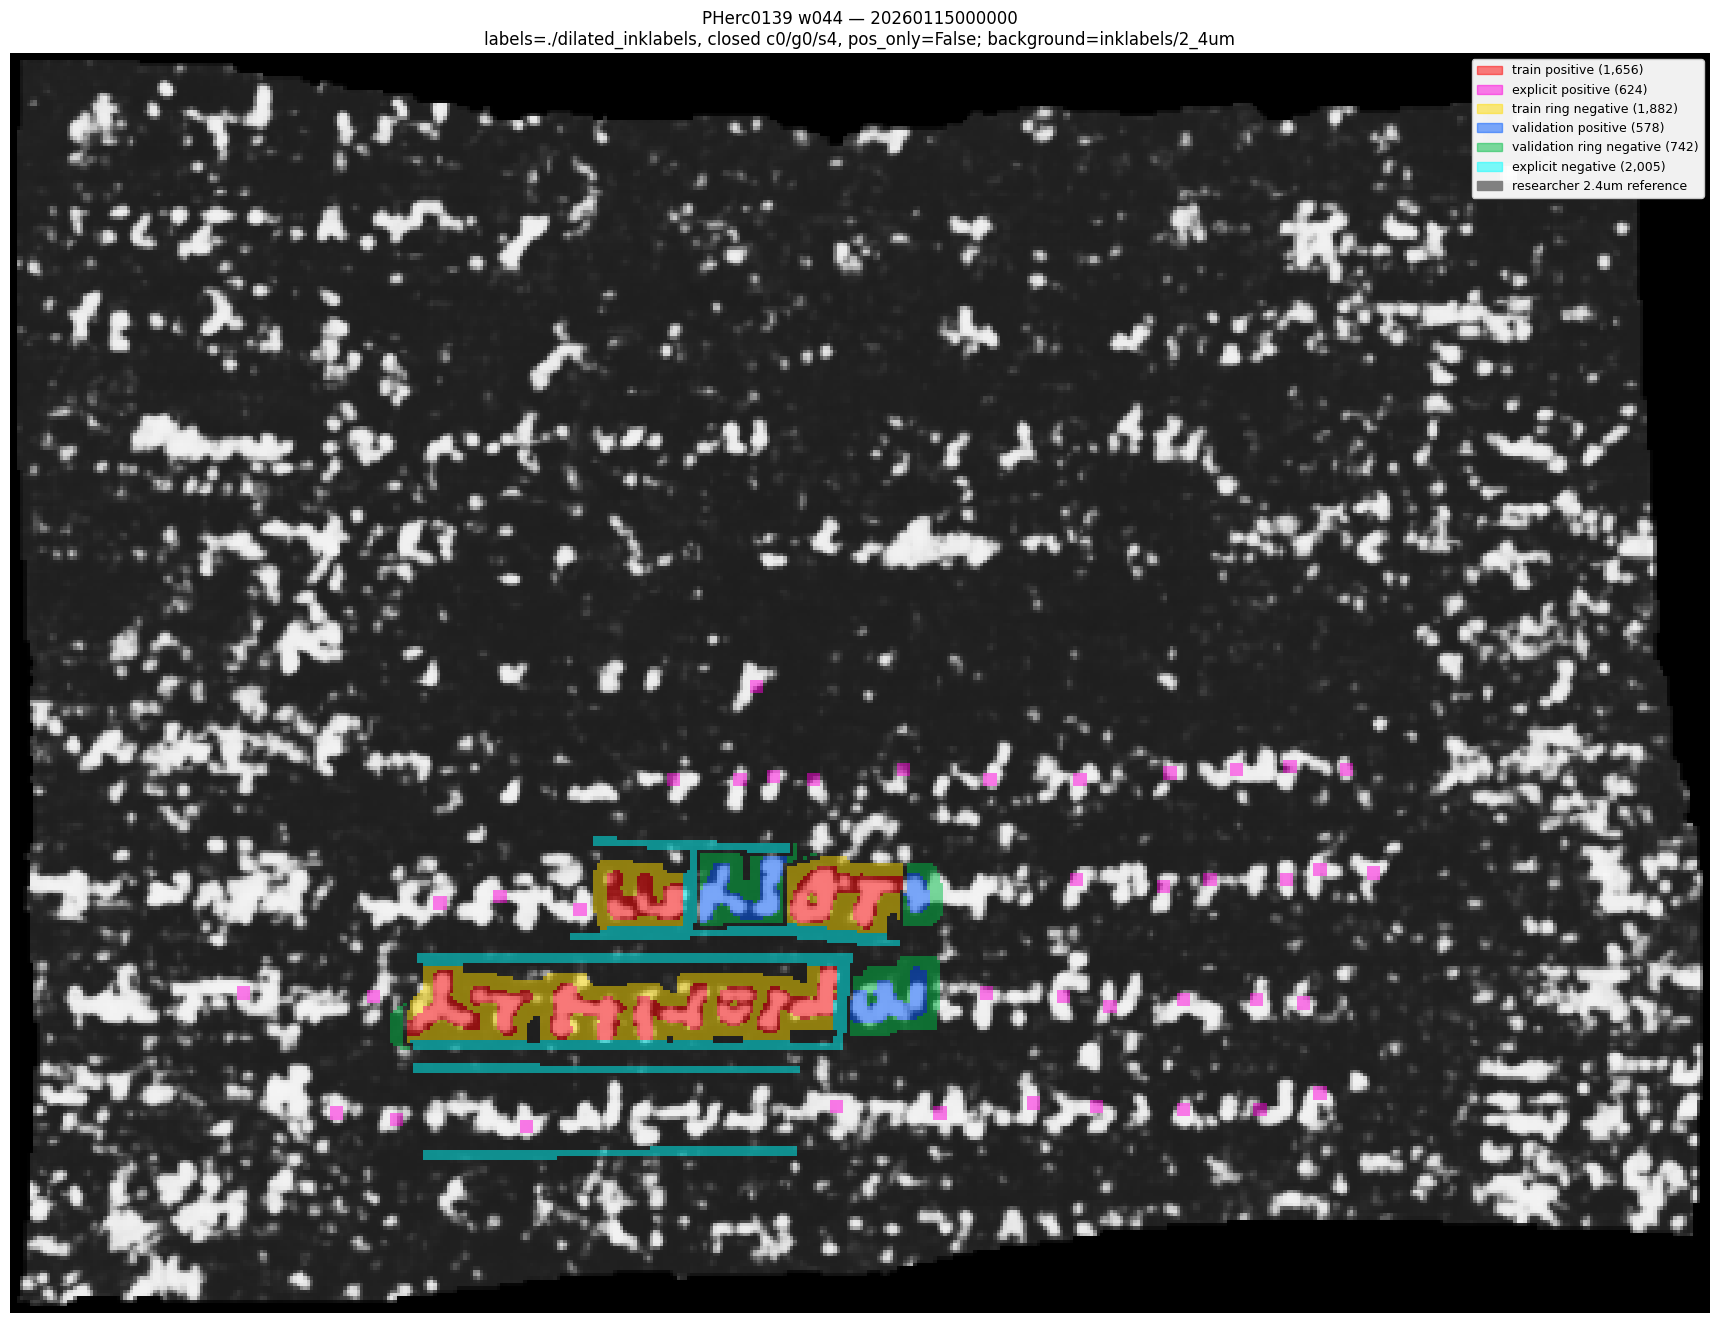

{'train_positive': 1656,
 'explicit_positive': 624,
 'train_negative': 1882,
 'valid_positive': 578,
 'valid_negative': 742,
 'explicit_negative': 2005}

In [8]:
# PHerc0139 w044
render_scroll(20260115000000, SCROLL_NAMES[20260115000000])

In [ ]:
# PHerc0139 w035
render_scroll(20260317000000, SCROLL_NAMES[20260317000000])

In [ ]:
# PHerc0139 w059
render_scroll(20250223000000, SCROLL_NAMES[20250223000000])

In [ ]:
# PHerc0139 w047
render_scroll(20260206000001, SCROLL_NAMES[20260206000001])

In [ ]:
# PHerc0139 w056
render_scroll(20260115000001, SCROLL_NAMES[20260115000001])

In [ ]:
# PHerc0139 w058
render_scroll(20260210000000, SCROLL_NAMES[20260210000000])

In [ ]:
# PHerc0139 w052
render_scroll(20260227000000, SCROLL_NAMES[20260227000000])

In [ ]:
# PHerc0139 w049
render_scroll(20260318000000, SCROLL_NAMES[20260318000000])

In [ ]:
# PHerc0139 w046
render_scroll(20260325000000, SCROLL_NAMES[20260325000000])

In [ ]:
# PHerc0139 w041
render_scroll(20260108000000, SCROLL_NAMES[20260108000000])

In [ ]:
# PHerc0139 w040
render_scroll(20250831000000, SCROLL_NAMES[20250831000000])

In [ ]:
# PHerc0139 w039
render_scroll(20260302000000, SCROLL_NAMES[20260302000000])

In [ ]:
# PHerc0139 w038
render_scroll(20260306000000, SCROLL_NAMES[20260306000000])

In [ ]:
# PHerc0139 w037
render_scroll(20260310000000, SCROLL_NAMES[20260310000000])

In [ ]:
# PHerc0139 w034
render_scroll(20260303000000, SCROLL_NAMES[20260303000000])

In [ ]:
# PHerc0139 w030 (new; researcher labels)
render_scroll(20250108000005, SCROLL_NAMES[20250108000005])

In [ ]:
# PHerc0139 w043 (new; researcher labels)
render_scroll(20260112000000, SCROLL_NAMES[20260112000000])

In [ ]:
# PHerc0139 w045 (new; researcher labels)
render_scroll(20260126000000, SCROLL_NAMES[20260126000000])

In [ ]:
# PHerc1667 w013
render_scroll(20240304141531, SCROLL_NAMES[20240304141531])

[split] scroll 20240304144031: manual mask=./train_masks/20240304144031.png train_pixels=11.8% explicit_negative_pixels=2,028,537 explicit_positive_pixels=493,545
[split] scroll 20240304144031: axis=x train_frac=0.75
[ring] closed(base=regular): CLOSE_R=0 GAP_R=0 exclusion_tiles=10576
[ring_negatives] source='closed' tile_radius=4  ink_tiles=13491  ring_tiles=18064  ratio=1.34
[manual-split] scroll 20240304144031: unit=16px train_ring=7199488px valid_ring=878592px
[context-replace] scroll 20240304144031: 87524 fully ink-free donors with mask>=0.80
saved /vesuvius/output/manual_split_audit/20240304144031_split_c0_g0_s4_dilated_inklabels.png
unique targets {'train_positive': 9287, 'explicit_positive': 1874, 'train_negative': 13842, 'valid_positive': 1273, 'valid_negative': 1858, 'explicit_negative': 5668}
train occurrences {'windows': 47720, 'positive_occurrences': 148592, 'negative_occurrences': 221472, 'explicit_positive_occurrences': 29984, 'explicit_negative_occurrences': 90688}
vali

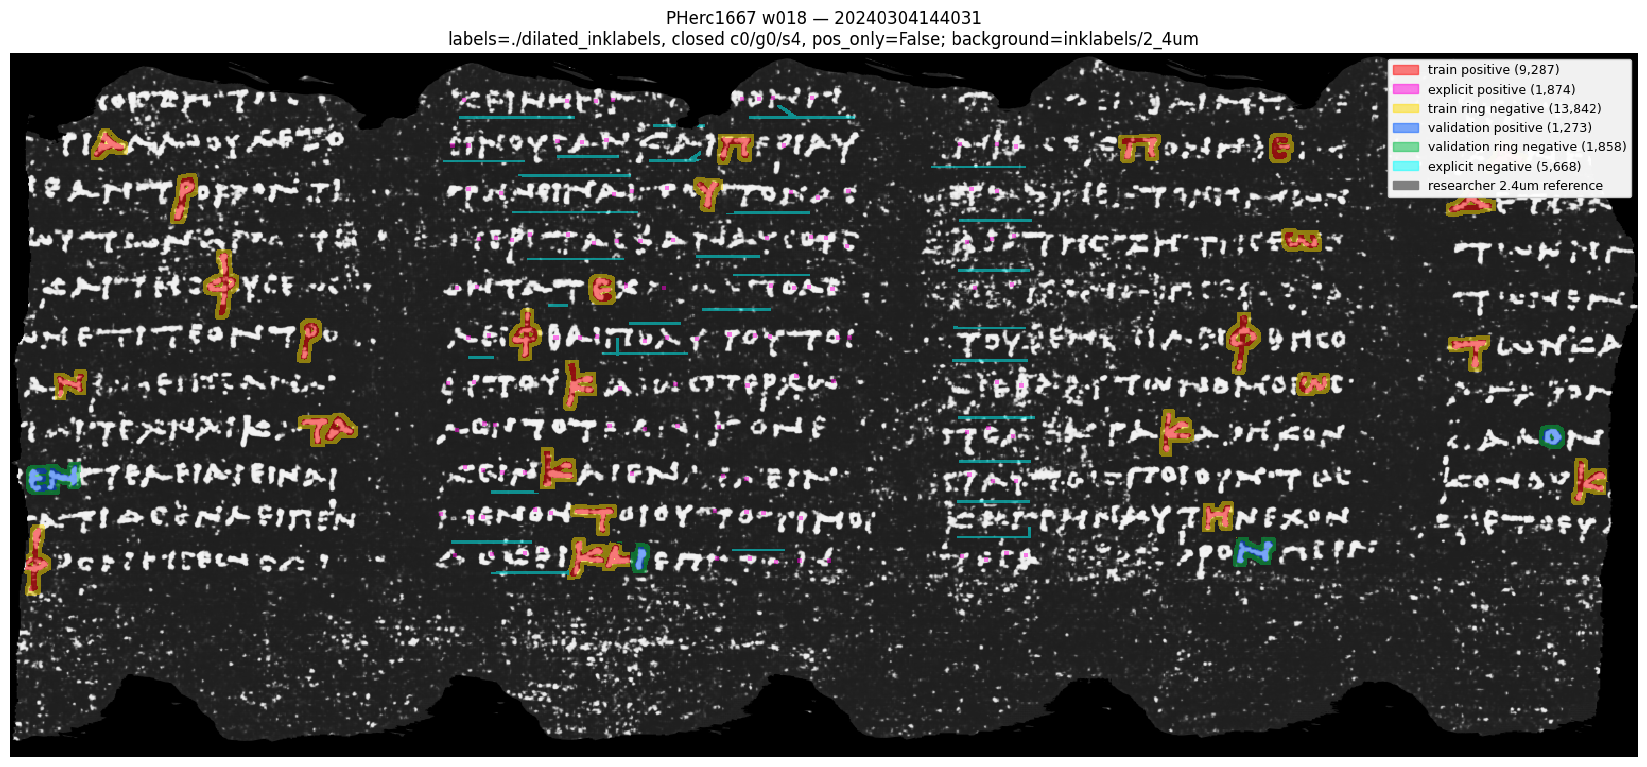

{'train_positive': 9287,
 'explicit_positive': 1874,
 'train_negative': 13842,
 'valid_positive': 1273,
 'valid_negative': 1858,
 'explicit_negative': 5668}

In [10]:
# PHerc1667 w018
render_scroll(20240304144031, SCROLL_NAMES[20240304144031])

In [ ]:
# PHerc1667 Cr1 Fr3
render_scroll(20231201215900, SCROLL_NAMES[20231201215900])

In [ ]:
# PHerc0172 w068
render_scroll(20251111010954, SCROLL_NAMES[20251111010954])

In [ ]:
# PHerc0172 w087
render_scroll(20251112000002, SCROLL_NAMES[20251112000002])

In [ ]:
# PHerc0009B patch 487
render_scroll(20250919125754, SCROLL_NAMES[20250919125754])

[split] scroll 20231210121321: manual mask=./train_masks/20231210121321.png train_pixels=19.7% explicit_negative_pixels=1,644,544 explicit_positive_pixels=0
[split] scroll 20231210121321: axis=x train_frac=0.75
[ring] closed(base=regular): CLOSE_R=0 GAP_R=0 exclusion_tiles=17558
[ring_negatives] source='closed' tile_radius=4  ink_tiles=17558  ring_tiles=29646  ratio=1.69
[manual-split] scroll 20231210121321: unit=16px train_ring=9027840px valid_ring=3056384px
[context-replace] scroll 20231210121321: 58871 fully ink-free donors with mask>=0.80
saved /vesuvius/output/manual_split_audit/20231210121321_split_c0_g0_s4_dilated_inklabels.png
unique targets {'train_positive': 13074, 'explicit_positive': 0, 'train_negative': 19455, 'valid_positive': 4332, 'valid_negative': 6455, 'explicit_negative': 4664}
train occurrences {'windows': 50007, 'positive_occurrences': 209184, 'negative_occurrences': 311280, 'explicit_positive_occurrences': 0, 'explicit_negative_occurrences': 74624}
valid occurrenc

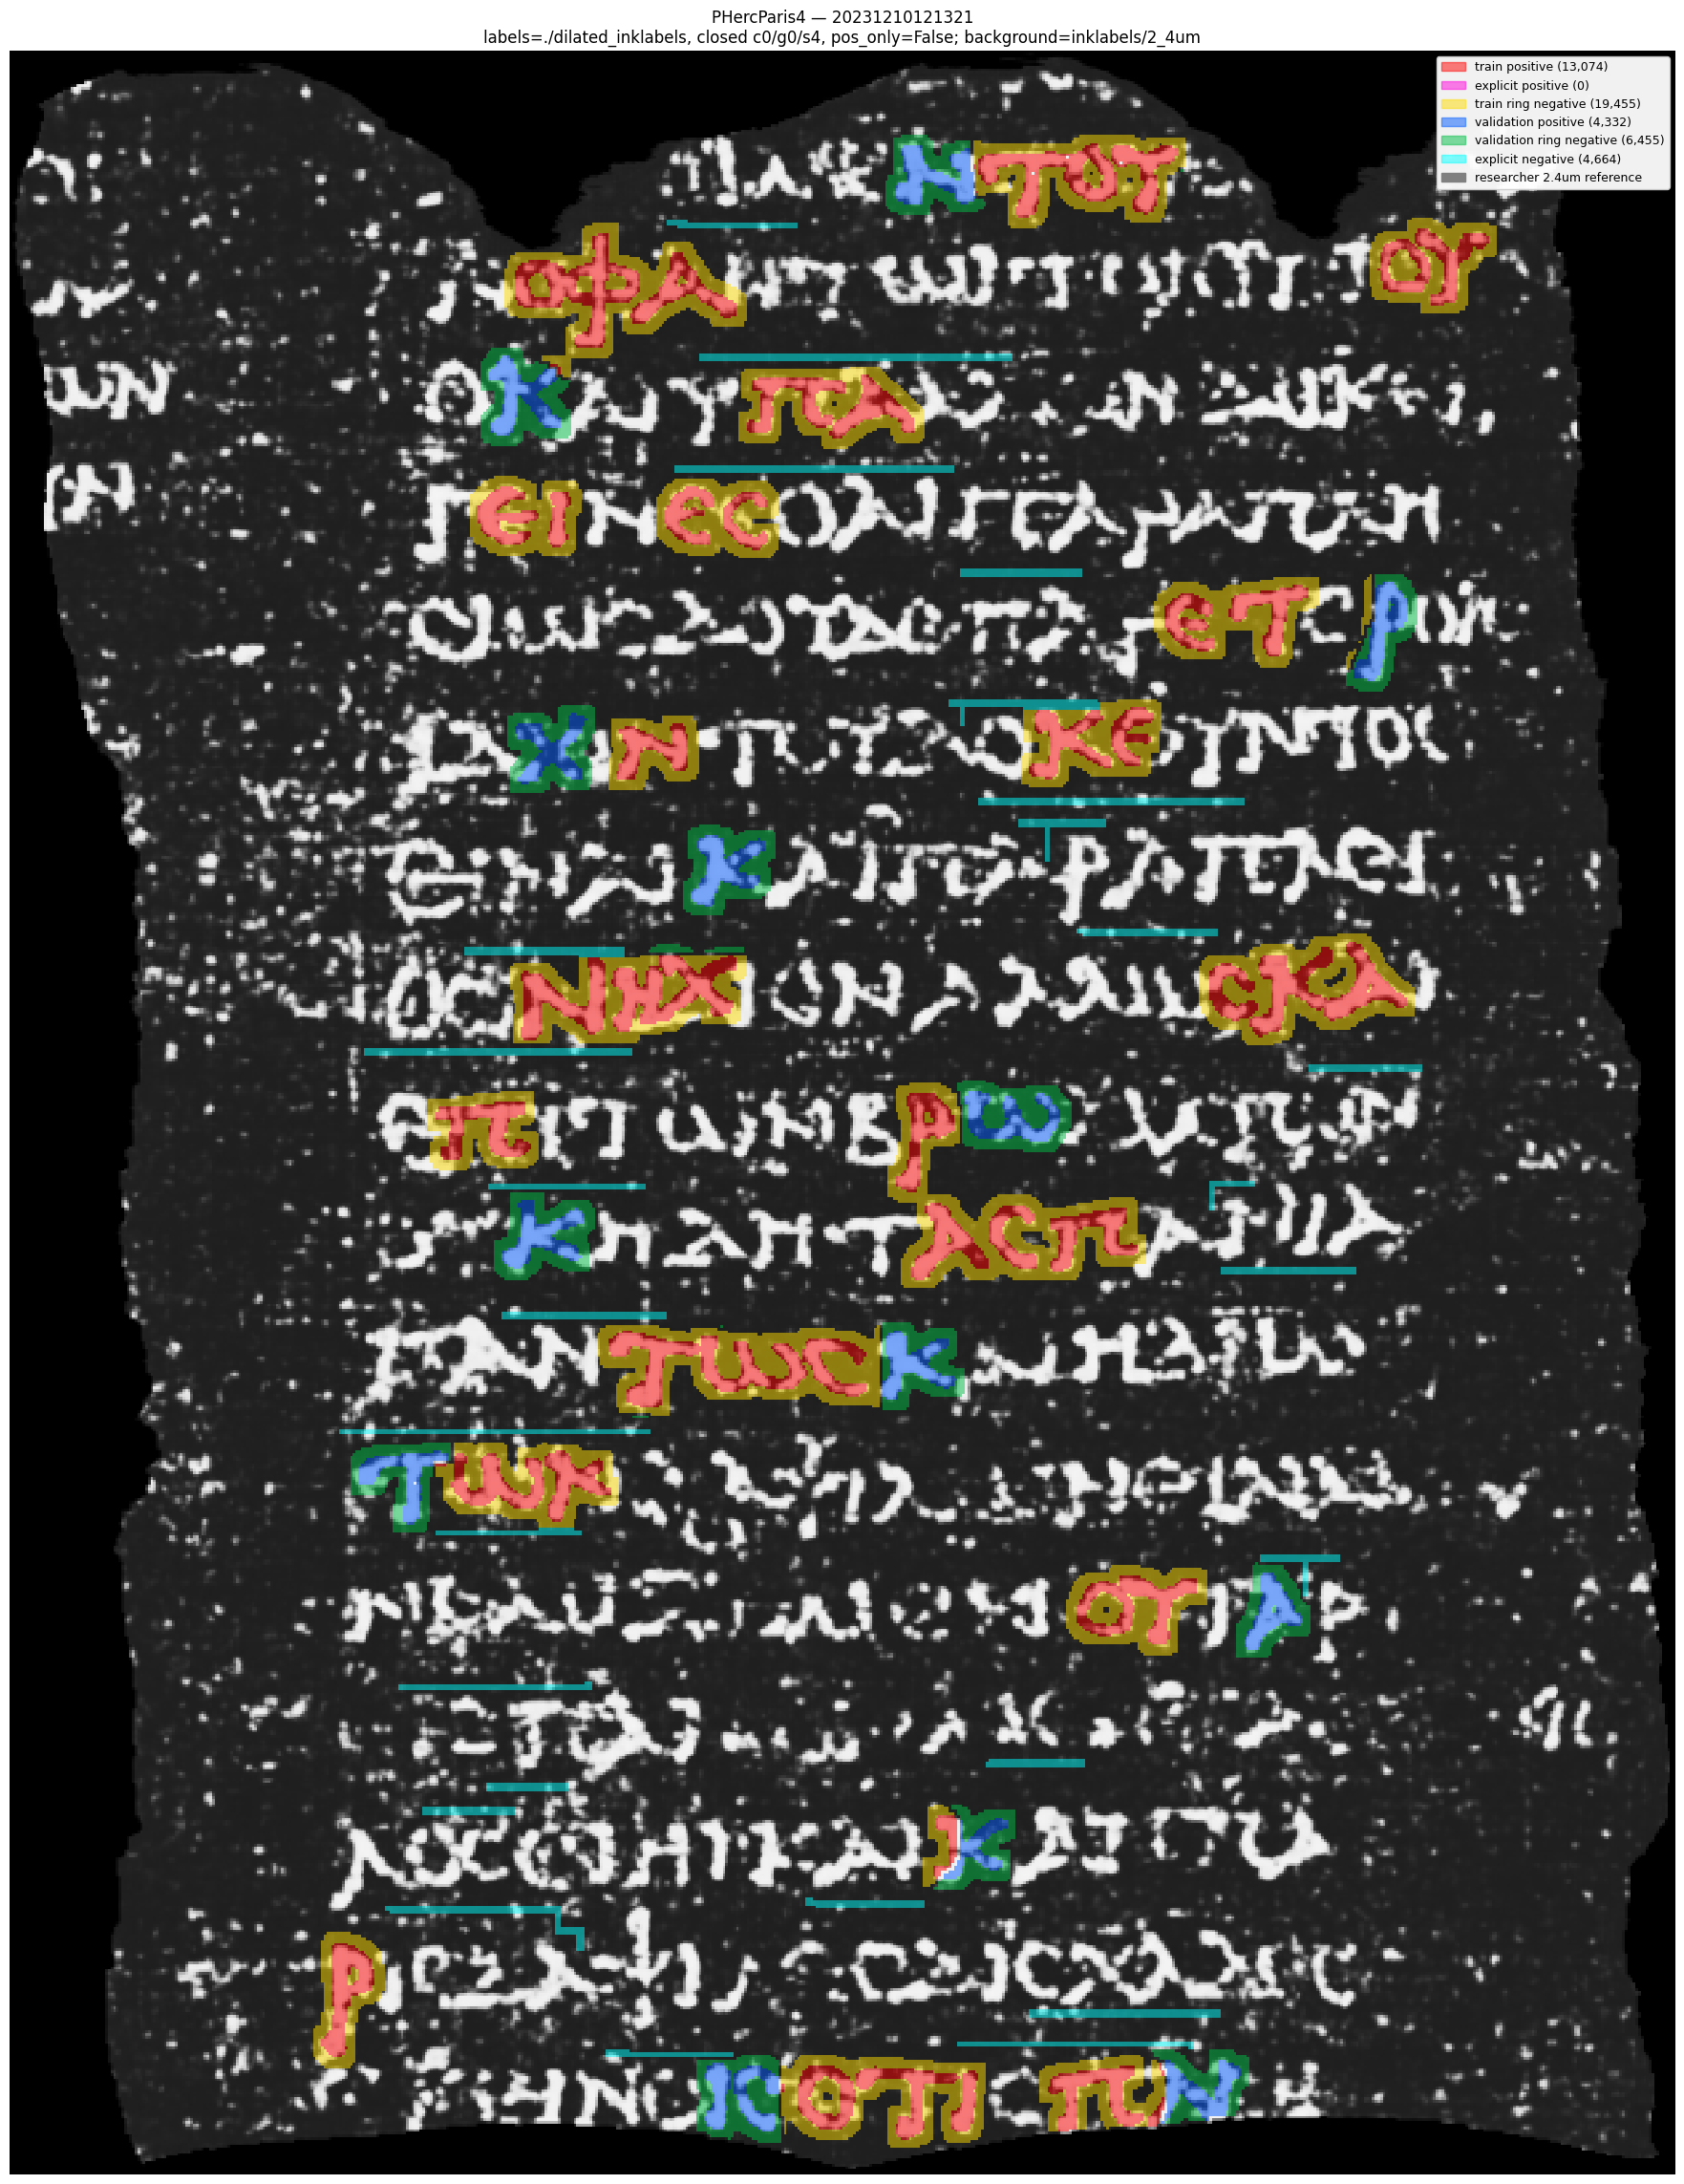

{'train_positive': 13074,
 'explicit_positive': 0,
 'train_negative': 19455,
 'valid_positive': 4332,
 'valid_negative': 6455,
 'explicit_negative': 4664}

In [9]:
# PHercParis4
render_scroll(20231210121321, SCROLL_NAMES[20231210121321])

In [ ]:
# PHerc0500P2 front
render_scroll(20250628074500, SCROLL_NAMES[20250628074500])

In [ ]:
# PHerc0814 seg46527
render_scroll(20260226000000, SCROLL_NAMES[20260226000000])

In [ ]:
# PHercParis2 Fr143
render_scroll(20230301213755, SCROLL_NAMES[20230301213755])

In [ ]:
# PHerc51 Cr4 Fr8
render_scroll(20231205222200, SCROLL_NAMES[20231205222200])

In [ ]:
# PHercParis1 Fr34
render_scroll(20230301213423, SCROLL_NAMES[20230301213423])

In [ ]:
# PHerc0343P
render_scroll(20250511003658, SCROLL_NAMES[20250511003658])

In [ ]:
# PHerc0841 auto-grown 405
render_scroll(20260221022814, SCROLL_NAMES[20260221022814])